# ch249 — Expected Value

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. The Weighted Average

The **expected value** (or **expectation**) of a random variable X is the probability-weighted average of all its possible values.

For a discrete RV:
$$E[X] = \sum_{x} x \cdot P(X = x)$$

For a continuous RV:
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x)\, dx$$

*(Sums from ch021; integrals from ch221.)*

Expected value is not the most likely outcome. It is the long-run average over infinitely many trials.

Fair die: E[X] = 3.5000
Note: 3.5 is never an actual outcome — expected value need not be attainable


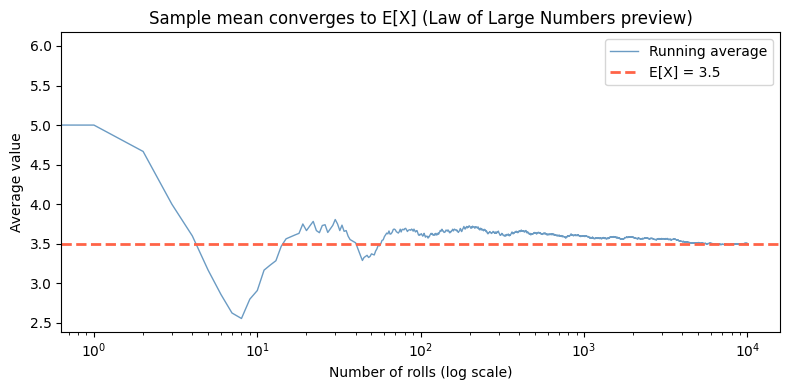

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Fair die: E[X] = (1+2+3+4+5+6)/6 = 3.5
faces = np.arange(1, 7)
pmf = np.full(6, 1/6)

E_X = np.sum(faces * pmf)
print(f"Fair die: E[X] = {E_X:.4f}")
print(f"Note: 3.5 is never an actual outcome — expected value need not be attainable")

# Empirical convergence: average approaches E[X] as n grows
rng = np.random.default_rng(seed=0)
n_max = 10_000
rolls = rng.integers(1, 7, size=n_max)
running_avg = np.cumsum(rolls) / np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(running_avg, color='steelblue', linewidth=1, alpha=0.8, label='Running average')
ax.axhline(3.5, color='tomato', linestyle='--', linewidth=2, label='E[X] = 3.5')
ax.set_xscale('log')
ax.set_xlabel('Number of rolls (log scale)')
ax.set_ylabel('Average value')
ax.set_title('Sample mean converges to E[X] (Law of Large Numbers preview)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Linearity of Expectation

This is one of the most useful properties in probability:
$$E[aX + bY] = aE[X] + bE[Y]$$

**This holds regardless of whether X and Y are independent.** Linearity requires no independence assumption.

*Proof*: Follows directly from the linearity of the sum/integral in the definition of E.*

In [2]:
# E[sum of two dice] = E[die1] + E[die2] = 3.5 + 3.5 = 7
# No independence argument needed — linearity alone suffices.

from itertools import product

Omega2 = list(product(range(1, 7), range(1, 7)))
prob = 1 / len(Omega2)

E_sum = sum((d1 + d2) * prob for d1, d2 in Omega2)
E_d1 = sum(d1 * prob for d1, _ in Omega2)
E_d2 = sum(d2 * prob for _, d2 in Omega2)

print(f"E[die1] = {E_d1:.4f}")
print(f"E[die2] = {E_d2:.4f}")
print(f"E[die1 + die2] = {E_sum:.4f}")
print(f"E[die1] + E[die2] = {E_d1 + E_d2:.4f}")
print(f"Linearity holds: {abs(E_sum - (E_d1 + E_d2)) < 1e-10}")

# Application: expected number of heads in n flips
n_flips = 10
p_heads = 0.5
# Each flip is Bernoulli(0.5) with E[X_i] = 0.5
E_total_heads = n_flips * p_heads
print(f"\nExpected heads in {n_flips} fair flips: {E_total_heads}")

E[die1] = 3.5000
E[die2] = 3.5000
E[die1 + die2] = 7.0000
E[die1] + E[die2] = 7.0000
Linearity holds: True

Expected heads in 10 fair flips: 5.0


## 3. Expectation of Functions: E[g(X)]

For a function g of a random variable X:
$$E[g(X)] = \sum_x g(x) \cdot P(X = x) \quad \text{(discrete)}$$

**Warning**: E[g(X)] ≠ g(E[X]) in general. This is **Jensen's inequality**: for convex g, E[g(X)] ≥ g(E[X]).

Fair die:
  E[X]   = 3.5000
  E[X]²  = 12.2500
  E[X²]  = 15.1667
  E[X²] >= E[X]²: True  (Jensen's inequality)
  Var(X) = E[X²] - E[X]² = 2.9167


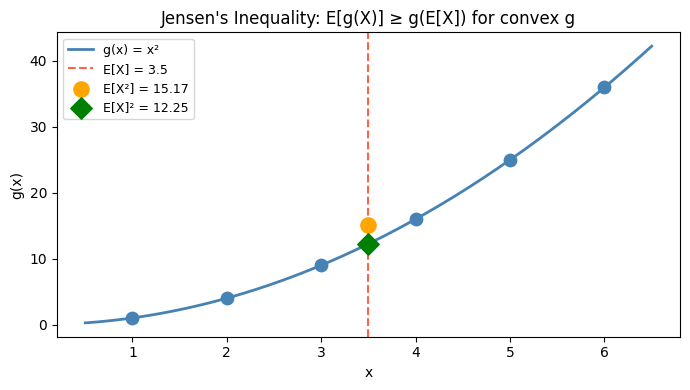

In [3]:
# Jensen's inequality: E[X^2] vs E[X]^2
# g(x) = x^2 is convex => E[X^2] >= E[X]^2

# Variance is defined as E[(X - mu)^2] = E[X^2] - E[X]^2
# This is always >= 0, which is Jensen's inequality in disguise

E_X_sq = np.sum(faces**2 * pmf)  # E[X^2] for fair die
E_X_2 = E_X ** 2                  # E[X]^2

print(f"Fair die:")
print(f"  E[X]   = {E_X:.4f}")
print(f"  E[X]²  = {E_X_2:.4f}")
print(f"  E[X²]  = {E_X_sq:.4f}")
print(f"  E[X²] >= E[X]²: {E_X_sq >= E_X_2}  (Jensen's inequality)")
print(f"  Var(X) = E[X²] - E[X]² = {E_X_sq - E_X_2:.4f}")

# Visual: convex function and Jensen's inequality
x_range = np.linspace(0.5, 6.5, 200)
g = x_range ** 2  # convex function

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_range, g, 'steelblue', linewidth=2, label='g(x) = x²')
ax.scatter(faces, faces**2, color='steelblue', zorder=5, s=80)
ax.axvline(E_X, color='tomato', linestyle='--', label=f'E[X] = {E_X}')
ax.scatter([E_X], [E_X_sq], color='orange', zorder=6, s=120, label=f'E[X²] = {E_X_sq:.2f}')
ax.scatter([E_X], [E_X_2], color='green', zorder=6, s=120, marker='D', label=f'E[X]² = {E_X_2:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('g(x)')
ax.set_title("Jensen's Inequality: E[g(X)] ≥ g(E[X]) for convex g")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Expected Value in Machine Learning

Loss functions in ML are expected values. The mean squared error (MSE) is:
$$\mathcal{L} = E\left[(y - \hat{y})^2\right]$$

The cross-entropy loss is:
$$\mathcal{L} = -E[\log P(y \mid x)]$$

Minimizing the loss is minimizing an expected value over the data distribution. Gradient descent *(from ch212)* is how we do it.

In [4]:
# MSE as empirical expectation over dataset
rng = np.random.default_rng(seed=42)

# Simulated dataset: y = 2x + noise
n = 100
x_data = rng.uniform(0, 5, n)
y_true = 2 * x_data + rng.normal(0, 0.5, n)

def mse(y_true, y_pred):
    """MSE = E[(y - ŷ)²] estimated from data."""
    return np.mean((y_true - y_pred)**2)  # mean = empirical expectation

# Compare two models
y_pred_good = 2.0 * x_data         # near-correct slope
y_pred_bad  = 1.0 * x_data + 2.0  # wrong model

print(f"MSE (good model): {mse(y_true, y_pred_good):.4f}")
print(f"MSE (bad model):  {mse(y_true, y_pred_bad):.4f}")
print("\nNote: MSE = (1/n) Σᵢ (yᵢ - ŷᵢ)² ≈ E[(y-ŷ)²]")
print("This is the population MSE estimated from a sample.")

MSE (good model): 0.2399
MSE (bad model):  2.3032

Note: MSE = (1/n) Σᵢ (yᵢ - ŷᵢ)² ≈ E[(y-ŷ)²]
This is the population MSE estimated from a sample.


## 5. Summary

- E[X] = Σ x·P(X=x) for discrete; ∫ x·f(x)dx for continuous.
- Expected value is the probability-weighted long-run average — not necessarily an attainable value.
- Linearity of expectation: E[aX + bY] = aE[X] + bE[Y], no independence required.
- E[g(X)] ≠ g(E[X]) in general — Jensen's inequality for convex g says E[g(X)] ≥ g(E[X]).
- Loss functions in ML are expectations; training minimizes them.

---

## 7. Forward References

Expected value summarizes the center of a distribution. Variance (ch250) summarizes its spread. Together, E[X] and Var(X) are the first two moments of a distribution — they appear in the Central Limit Theorem (ch254) and form the basis of moment-matching methods in statistics.